<a href="https://colab.research.google.com/github/ashiali09/Final-Year-Project/blob/main/RCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model=torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

In [ ]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
!wget 'file:///C:/Users/HP/Pictures/istockphoto-940320814-612x612.jpg'

file:///C:/Users/HP/Pictures/istockphoto-940320814-612x612.jpg: Unsupported scheme ‘file’.


In [ ]:
ig = Image.open("/content/istockphoto-940320814-612x612.jpg")

In [ ]:
transform = T.ToTensor()
img=transform(ig)

In [ ]:
with torch.no_grad():
  pred = model([img])

In [ ]:
pred

[{'boxes': tensor([[7.9111e+01, 2.7011e+02, 1.6930e+02, 4.0377e+02],
          [4.3620e+02, 1.3357e+02, 5.8502e+02, 4.0408e+02],
          [2.7091e+02, 2.1213e+02, 2.9458e+02, 2.4927e+02],
          [1.4993e+02, 1.9558e+02, 1.6012e+02, 2.4299e+02],
          [7.5871e+01, 6.7738e+01, 1.1449e+02, 8.4882e+01],
          [2.5468e+01, 2.3530e+02, 3.7279e+01, 2.6924e+02],
          [1.2278e+02, 1.9760e+02, 1.3033e+02, 2.4349e+02],
          [2.2984e+02, 2.5767e+02, 2.7390e+02, 2.7195e+02],
          [1.0227e+02, 1.9705e+02, 1.1324e+02, 2.4322e+02],
          [3.9805e+02, 2.4182e+02, 4.0908e+02, 2.6904e+02],
          [8.8263e+01, 1.2517e+02, 1.1090e+02, 1.3698e+02],
          [4.0994e+02, 2.3995e+02, 4.2349e+02, 2.6976e+02],
          [1.9621e+02, 2.2591e+02, 2.1213e+02, 2.4205e+02],
          [1.3526e+02, 1.9640e+02, 1.4289e+02, 2.4271e+02],
          [6.8870e+01, 2.3246e+02, 7.6995e+01, 2.4950e+02],
          [5.7681e+01, 2.3423e+02, 6.8217e+01, 2.5071e+02],
          [1.6108e+02, 1.2509e+

In [ ]:
len(pred)

1

In [ ]:
type(pred)

list

In [ ]:
pred[0].keys()

dict_keys(['boxes', 'labels', 'scores'])

In [ ]:
bboxes , label , scores = pred[0]["boxes"],pred[0]["labels"],pred[0]["scores"],

In [ ]:
scores

tensor([0.9988, 0.9985, 0.9899, 0.9762, 0.9759, 0.9668, 0.9666, 0.9666, 0.9268,
        0.9245, 0.9079, 0.8894, 0.8802, 0.8747, 0.8512, 0.8346, 0.8169, 0.8146,
        0.7954, 0.7417, 0.7227, 0.7203, 0.6941, 0.6736, 0.6702, 0.6545, 0.6415,
        0.6334, 0.6106, 0.6106, 0.5481, 0.5421, 0.5343, 0.5085, 0.4836, 0.4627,
        0.4494, 0.4315, 0.4276, 0.4184, 0.4147, 0.4137, 0.4056, 0.3939, 0.3938,
        0.3775, 0.3674, 0.3422, 0.3342, 0.3232, 0.3007, 0.2966, 0.2954, 0.2921,
        0.2873, 0.2838, 0.2822, 0.2592, 0.2517, 0.2463, 0.2451, 0.2450, 0.2406,
        0.2329, 0.2290, 0.2125, 0.2125, 0.2111, 0.1930, 0.1867, 0.1853, 0.1816,
        0.1763, 0.1481, 0.1473, 0.1455, 0.1279, 0.1149, 0.1135, 0.1132, 0.1131,
        0.1099, 0.1084, 0.1062, 0.0957, 0.0936, 0.0922, 0.0896, 0.0813, 0.0745,
        0.0678, 0.0662, 0.0653, 0.0575, 0.0539, 0.0531, 0.0530, 0.0505])

In [ ]:
num=torch.argwhere( scores > 0.9 ).shape[0]

In [ ]:
torch.argwhere( scores > 0.9 ).shape[0]

11

In [ ]:
coco_names = ["person" , "bicycle" , "car" , "motorcycle" , "airplane" , "bus" , "train" , "truck" , "boat" , "traffic light" , "fire hydrant" , "street sign" , "stop sign" , "parking meter" , "bench" , "bird" , "cat" , "dog" , "horse" , "sheep" , "cow" , "elephant" , "bear" , "zebra" , "giraffe" , "hat" , "backpack" , "umbrella" , "shoe" , "eye glasses" , "handbag" , "tie" , "suitcase" ,
"frisbee" , "skis" , "snowboard" , "sports ball" , "kite" , "baseball bat" ,
"baseball glove" , "skateboard" , "surfboard" , "tennis racket" , "bottle" ,
"plate" , "wine glass" , "cup" , "fork" , "knife" , "spoon" , "bowl" ,
"banana" , "apple" , "sandwich" , "orange" , "broccoli" , "carrot" , "hot dog" ,
"pizza" , "donut" , "cake" , "chair" , "couch" , "potted plant" , "bed" ,
"mirror" , "dining table" , "window" , "desk" , "toilet" , "door" , "tv" ,
"laptop" , "mouse" , "remote" , "keyboard" , "cell phone" , "microwave" ,
"oven" , "toaster" , "sink" , "refrigerator" , "blender" , "book" ,
"clock" , "vase" , "scissors" , "teddy bear" , "hair drier" , "toothbrush" , "hair brush"]


In [ ]:
font = cv2.FONT_HERSHEY_SIMPLEX

In [ ]:
igg = cv2.imread("/content/istockphoto-940320814-612x612.jpg")

for i in range(num):
    x1, y1, x2, y2 = bboxes[i].numpy().astype("int")
    class_name = coco_names[label.numpy()[i]-1]
    igg = cv2.rectangle(igg,(x1,y1),(x2,y2),(0,255,0),1)
    igg = cv2.putText(igg, class_name, (x1, y1 - 10), font, 0.5, (255, 0, 0), 1, cv2.LINE_AA)



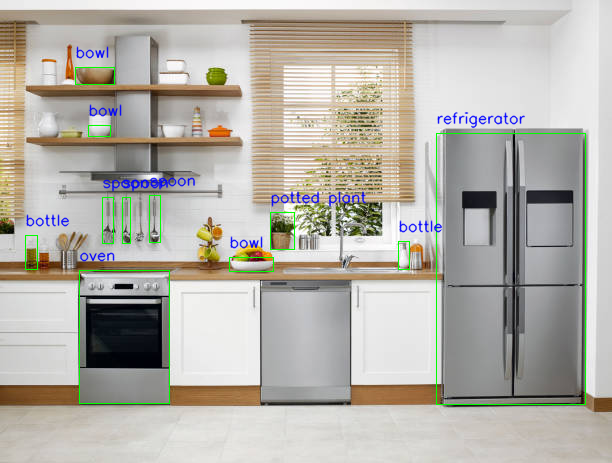

In [ ]:
cv2_imshow(igg)

In [ ]:
label

tensor([79, 82, 64, 50, 51, 44, 50, 51, 50, 44, 51, 44, 52, 50, 50, 50, 51, 51,
        82, 44, 44, 50, 52, 51, 81, 50, 50, 50, 47, 50, 55, 52, 50, 53, 52, 81,
        44, 51, 64, 47, 44, 50, 86, 50, 52, 53, 51, 64, 52, 52, 50, 52, 50, 81,
        50, 64, 50, 52, 81, 81, 86, 53, 86, 50, 51, 50, 50, 55, 81, 55, 86, 79,
        64, 47, 64, 47, 51, 55, 64, 64, 52, 50, 81, 81, 51, 53, 47, 52, 47, 49,
        44, 47, 49, 50, 51, 49, 81, 55])

In [ ]:
bboxes

tensor([[7.9111e+01, 2.7011e+02, 1.6930e+02, 4.0377e+02],
        [4.3620e+02, 1.3357e+02, 5.8502e+02, 4.0408e+02],
        [2.7091e+02, 2.1213e+02, 2.9458e+02, 2.4927e+02],
        [1.4993e+02, 1.9558e+02, 1.6012e+02, 2.4299e+02],
        [7.5871e+01, 6.7738e+01, 1.1449e+02, 8.4882e+01],
        [2.5468e+01, 2.3530e+02, 3.7279e+01, 2.6924e+02],
        [1.2278e+02, 1.9760e+02, 1.3033e+02, 2.4349e+02],
        [2.2984e+02, 2.5767e+02, 2.7390e+02, 2.7195e+02],
        [1.0227e+02, 1.9705e+02, 1.1324e+02, 2.4322e+02],
        [3.9805e+02, 2.4182e+02, 4.0908e+02, 2.6904e+02],
        [8.8263e+01, 1.2517e+02, 1.1090e+02, 1.3698e+02],
        [4.0994e+02, 2.3995e+02, 4.2349e+02, 2.6976e+02],
        [1.9621e+02, 2.2591e+02, 2.1213e+02, 2.4205e+02],
        [1.3526e+02, 1.9640e+02, 1.4289e+02, 2.4271e+02],
        [6.8870e+01, 2.3246e+02, 7.6995e+01, 2.4950e+02],
        [5.7681e+01, 2.3423e+02, 6.8217e+01, 2.5071e+02],
        [1.6108e+02, 1.2509e+02, 1.8535e+02, 1.3744e+02],
        [5.845